<a href="https://colab.research.google.com/github/avionerman/neural-networks-msc/blob/main/%5BREPORT%5D_dcnn_deepfake_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

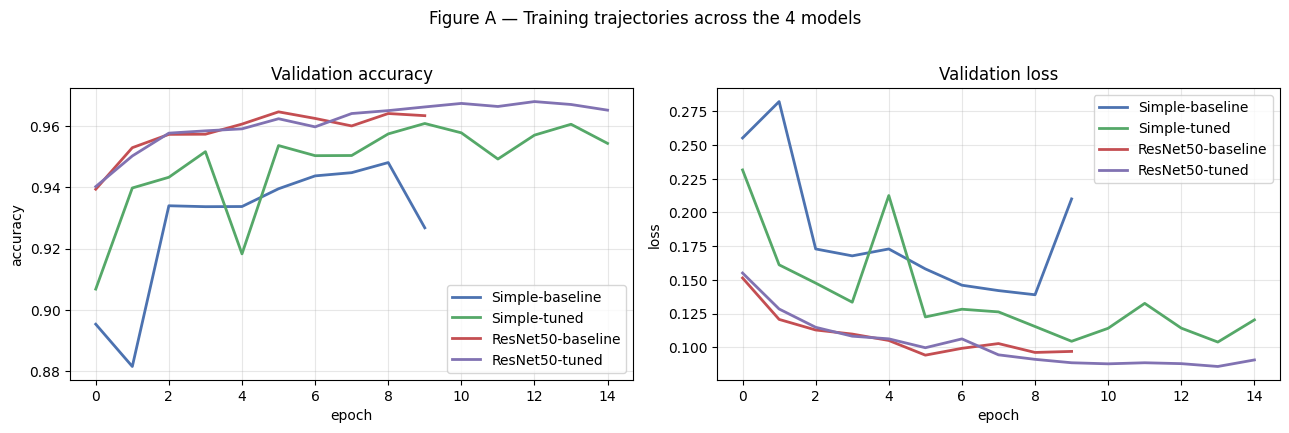

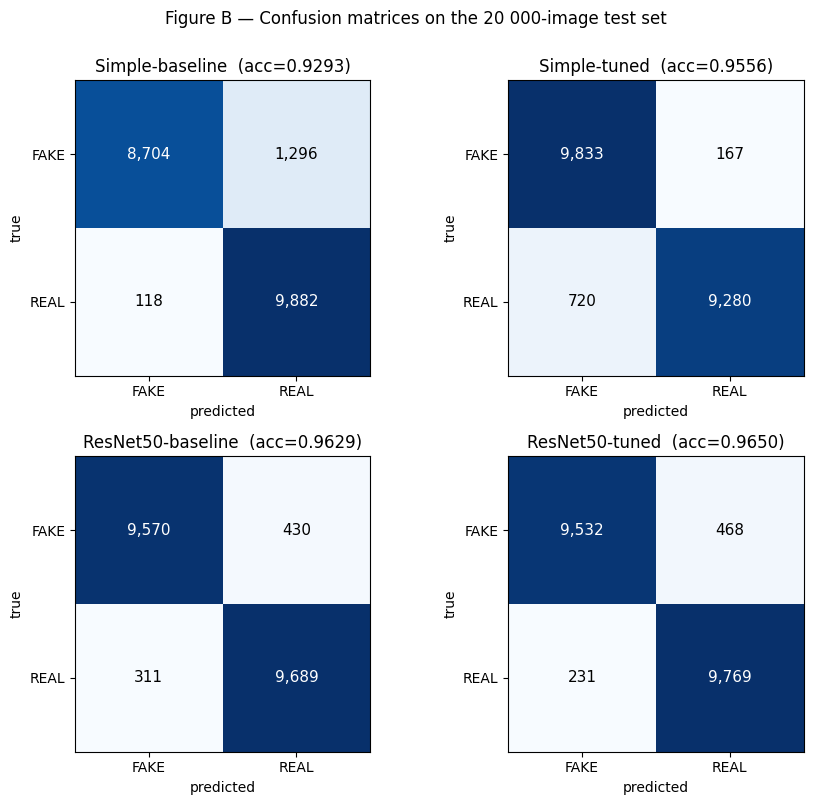

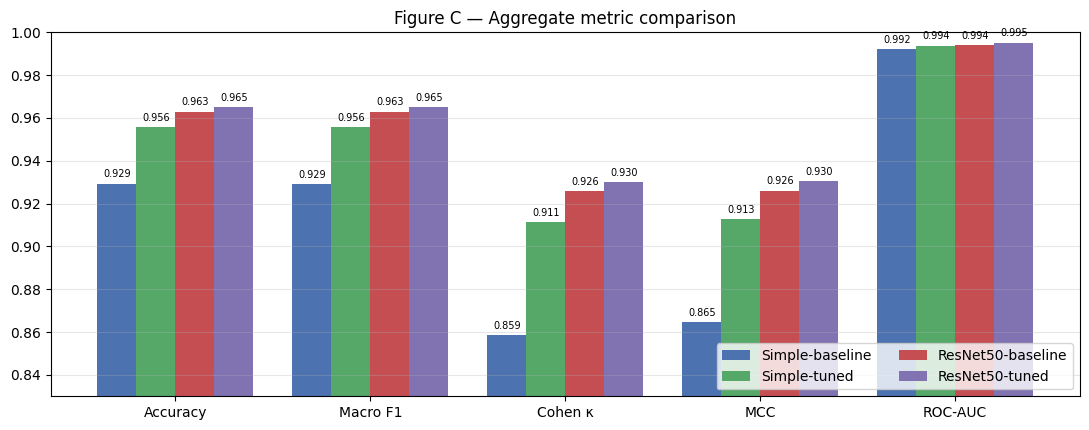

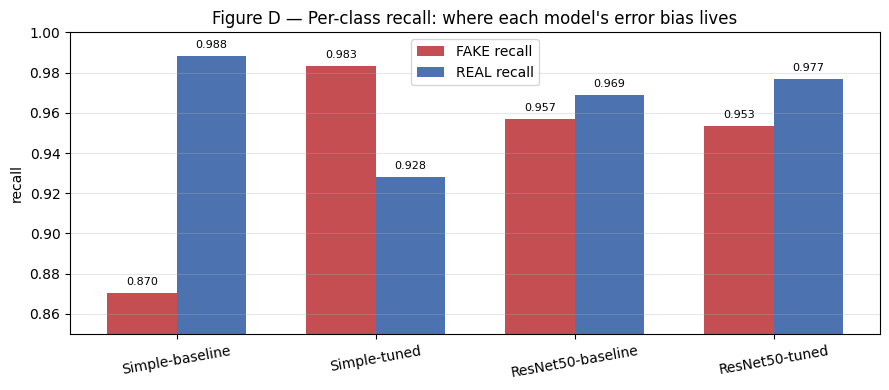

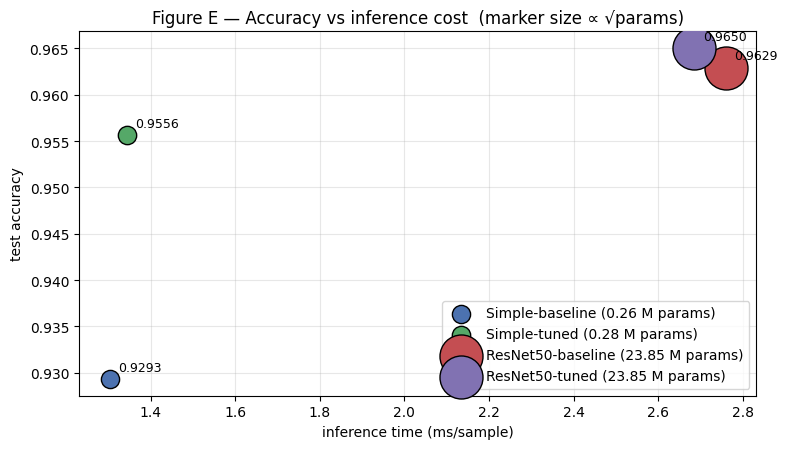

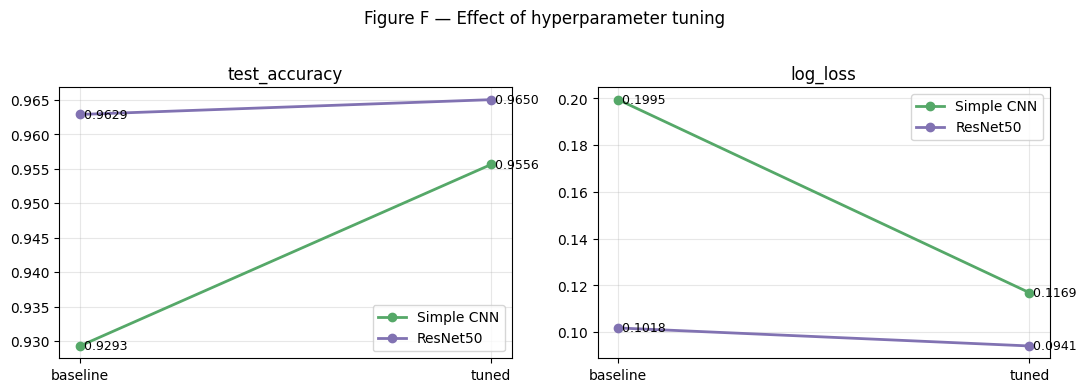

fig_accuracy_vs_cost.png 77573 bytes
fig_aggregate_metrics.png 55803 bytes
fig_confusion_matrices.png 72928 bytes
fig_per_class_recall.png 54484 bytes
fig_training_curves.png 140178 bytes
fig_tuning_effect.png 81098 bytes


In [25]:
import json, numpy as np, matplotlib.pyplot as plt

with open("deepfake_results.json") as f:
    R = json.load(f)

models = ["simple_baseline", "simple_tuned", "resnet_baseline", "resnet_tuned"]
labels = ["Simple-baseline", "Simple-tuned", "ResNet50-baseline", "ResNet50-tuned"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
SAVE = dict(dpi=130, bbox_inches="tight")

# A) training curves
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for m, lbl, c in zip(models, labels, colors):
    h = R["models"][m]["history"]
    ax[0].plot(h["val_accuracy"], label=lbl, color=c, lw=2)
    ax[1].plot(h["val_loss"], label=lbl, color=c, lw=2)
ax[0].set_title("Validation accuracy"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("accuracy"); ax[0].grid(alpha=.3); ax[0].legend()
ax[1].set_title("Validation loss"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("loss"); ax[1].grid(alpha=.3); ax[1].legend()
fig.suptitle("Figure A — Training trajectories across the 4 models", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("fig_training_curves.png", **SAVE)
plt.show()

# B) confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
class_names = R["metadata"]["class_names"]
for ax_, m, lbl in zip(axes.ravel(), models, labels):
    cm = np.array(R["models"][m]["confusion_matrix"])
    ax_.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax_.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                     color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=11)
    ax_.set_xticks([0,1], class_names); ax_.set_yticks([0,1], class_names)
    ax_.set_xlabel("predicted"); ax_.set_ylabel("true")
    ax_.set_title(f"{lbl}  (acc={R['models'][m]['test_accuracy']:.4f})")
fig.suptitle("Figure B — Confusion matrices on the 20 000-image test set", y=1.00, fontsize=12)
plt.tight_layout()
plt.savefig("fig_confusion_matrices.png", **SAVE)
plt.show()

# C) aggregate metrics
keys = ["test_accuracy", "f1_macro", "cohen_kappa", "matthews_corrcoef", "roc_auc"]
labs = ["Accuracy", "Macro F1", "Cohen κ", "MCC", "ROC-AUC"]
x = np.arange(len(labs)); w = 0.2
fig, ax = plt.subplots(figsize=(11, 4.4))
for i, (m, lbl, c) in enumerate(zip(models, labels, colors)):
    vals = [R["models"][m][k] for k in keys]
    bars = ax.bar(x + (i-1.5)*w, vals, w, label=lbl, color=c)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.003, f"{v:.3f}", ha="center", fontsize=7)
ax.set_xticks(x, labs); ax.set_ylim(0.83, 1.0); ax.grid(axis="y", alpha=.3)
ax.set_title("Figure C — Aggregate metric comparison")
ax.legend(loc="lower right", ncol=2)
plt.tight_layout()
plt.savefig("fig_aggregate_metrics.png", **SAVE)
plt.show()

# D) per-class recall
fake = [R["models"][m]["per_class_accuracy"]["FAKE"] for m in models]
real = [R["models"][m]["per_class_accuracy"]["REAL"] for m in models]
x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - w/2, fake, w, label="FAKE recall", color="#C44E52")
b2 = ax.bar(x + w/2, real, w, label="REAL recall", color="#4C72B0")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004, f"{b.get_height():.3f}", ha="center", fontsize=8)
ax.set_xticks(x, labels, rotation=10); ax.set_ylim(0.85, 1.0)
ax.set_ylabel("recall"); ax.grid(axis="y", alpha=.3); ax.legend()
ax.set_title("Figure D — Per-class recall: where each model's error bias lives")
plt.tight_layout()
plt.savefig("fig_per_class_recall.png", **SAVE)
plt.show()

# E) accuracy vs cost
accs  = [R["models"][m]["test_accuracy"] for m in models]
times = [R["models"][m]["inference_time_per_sample_ms"] for m in models]
params = [R["models"][m]["num_total_params"]/1e6 for m in models]
fig, ax = plt.subplots(figsize=(8, 4.6))
for a, t, p, lbl, c in zip(accs, times, params, labels, colors):
    ax.scatter(t, a, s=80 + 18*np.sqrt(p*1e6)/100, color=c, edgecolor="black", zorder=3, label=f"{lbl} ({p:.2f} M params)")
    ax.annotate(f"{a:.4f}", (t, a), xytext=(6, 6), textcoords="offset points", fontsize=9)
ax.set_xlabel("inference time (ms/sample)"); ax.set_ylabel("test accuracy")
ax.set_title("Figure E — Accuracy vs inference cost  (marker size ∝ √params)")
ax.grid(alpha=.3); ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("fig_accuracy_vs_cost.png", **SAVE)
plt.show()

# F) tuning effect
pairs = [("simple_baseline", "simple_tuned", "Simple CNN"),
         ("resnet_baseline", "resnet_tuned", "ResNet50")]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for k, key in enumerate(["test_accuracy", "log_loss"]):
    for i, (b, t, name) in enumerate(pairs):
        v_b, v_t = R["models"][b][key], R["models"][t][key]
        ax[k].plot([0, 1], [v_b, v_t], "-o", color=colors[i*2+1], lw=2, label=name)
        ax[k].text(0, v_b, f" {v_b:.4f}", va="center", fontsize=9)
        ax[k].text(1, v_t, f" {v_t:.4f}", va="center", fontsize=9)
    ax[k].set_xticks([0, 1], ["baseline", "tuned"])
    ax[k].set_title(key); ax[k].grid(alpha=.3); ax[k].legend()
fig.suptitle("Figure F — Effect of hyperparameter tuning", y=1.02)
plt.tight_layout()
plt.savefig("fig_tuning_effect.png", **SAVE)
plt.show()

# verify
import os
for f in sorted(os.listdir()):
    if f.endswith(".png"):
        print(f, os.path.getsize(f), "bytes")



# Ανιχνευση Deepfake στο CIFAKE, Αναφορα Εργασιας

**Προβλημα:** δυαδικη ταξινομηση πραγματικων εικονων εναντι εικονων παραγομενων απο AI (CIFAKE, 50 000 εικονες training, 20 000 test, αναβαθμισμενες απο 32×32).

**Μοντελα προς συγκριση:** ενα custom Simple CNN (baseline και tuned) και ενα ResNet50 με transfer learning (baseline και tuned).

**Tuning:** Keras Tuner πανω σε `dropout`, `dense_units`, `learning_rate`, με 5 trials ανα αρχιτεκτονικη. Η καλυτερη διαμορφωση εκπαιδευτηκε ξανα για 15 epochs (αντι 10 του baseline).

---

## 1. Συνοπτικο αποτελεσμα

Εκπαιδευσα τις τεσσερις διαμορφωσεις end-to-end. Το tuned ResNet50 κερδιζει σε καθε aggregate μετρικη, αλλα το tuned Simple CNN βρισκεται λιγοτερο απο 1 ποσοστιαια μοναδα πισω (0.9651 εναντι 0.9557), με το μισο κοστος inference (1.34 ms εναντι 2.69 ms ανα δειγμα) και το 1/90 του αριθμου παραμετρων (0.28 M εναντι 23.85 M).

| Μοντελο | Παραμετροι (trainable) | Test Acc | Macro F1 | Cohen κ | MCC | ROC-AUC | Log Loss | Inference (ms/sample) |
|---|---|---|---|---|---|---|---|---|
| Simple CNN, baseline | 259K (258K) | 0.9293 | 0.9291 | 0.8586 | 0.8646 | 0.9922 | 0.1995 | 1.30 |
| Simple CNN, tuned | 276K (275K) | **0.9557** | **0.9556** | **0.9113** | **0.9127** | 0.9937 | 0.1169 | 1.34 |
| ResNet50, baseline | 23.85M (263K) | 0.9629 | 0.9629 | 0.9259 | 0.9260 | 0.9939 | 0.1018 | 2.76 |
| ResNet50, tuned | 23.85M (263K) | **0.9651** | **0.9650** | **0.9301** | **0.9304** | **0.9952** | **0.0941** | 2.69 |


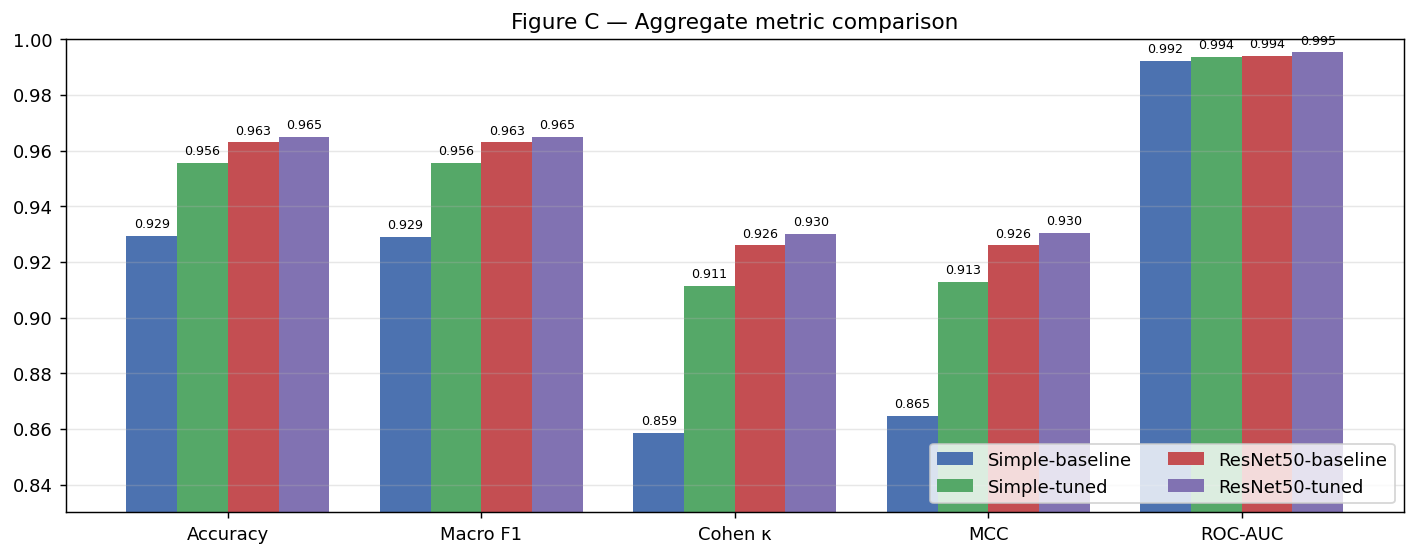


**Επισημανση:** ολα τα μοντελα ξεπερνουν το 0.99 ROC-AUC, αρα το διακριτικο σημα στο CIFAKE ειναι ισχυρο. Αυτο που τα διαφοροποιει ειναι η βαθμονομηση (calibration) και η ισορροπια ανα κλαση, οχι η διαχωρισιμοτητα.

---

## 2. Δυναμικη εκπαιδευσης


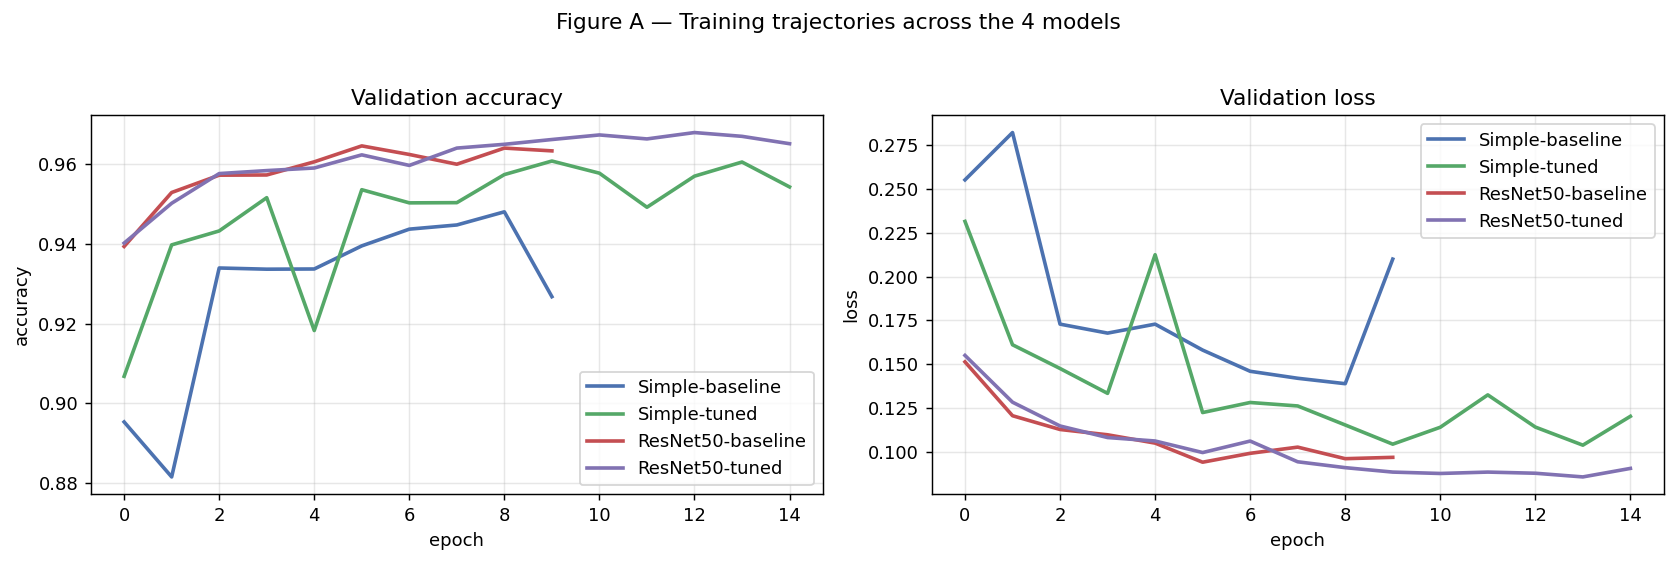


Και τα δυο ResNet50 συγκλινουν στο plateau τους μεσα σε περιπου 5 epochs και παραμενουν εκει. Το Simple-baseline δεν σταθεροποιειται ποτε. Η εκτιναξη του val-loss στο epoch 9 (απο 0.139 σε 0.210) ειναι η κλασικη υπογραφη overfitting σε ενα υπο-κανονικοποιημενο μικρο CNN με υπερβολικα υψηλο learning rate (lr=1e-3, dropout=0.4). Το Simple-tuned (lr=1e-4, dropout=0.2, 15 epochs) ειναι θορυβωδες αλλα σταθεροποιειται στη ζωνη 0.955 ως 0.961, που μου δειχνει οτι το bottleneck δεν ηταν η αρχιτεκτονικη αλλα οι ρυθμισεις του optimizer.

**Επισημανση:** το σπασιμο της καμπυλης του Simple-baseline στο τελευταιο epoch ειναι το πιο εμφανες σημειο στο γραφημα, ξεκινα την εξηγηση απο εκει.

---

## 3. Πινακες συγχυσης και bias ανα κλαση


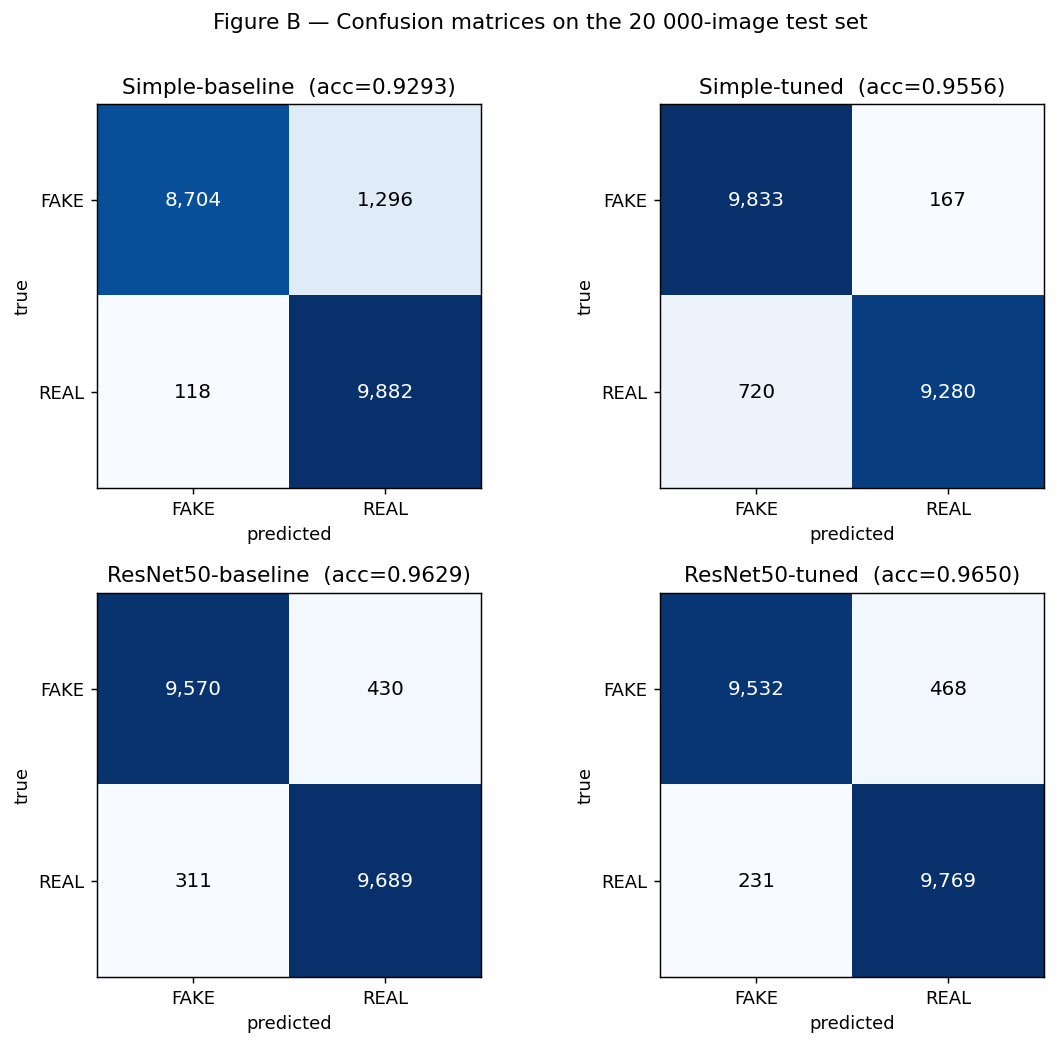

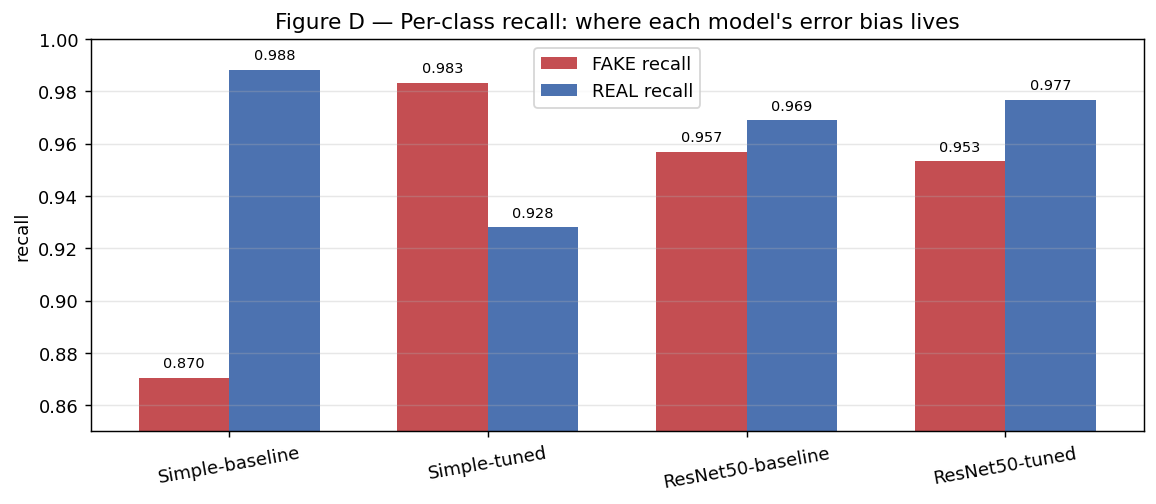


|  | FAKE recall | REAL recall | FAKE precision | REAL precision | Μοτιβο σφαλματος |
|---|---|---|---|---|---|
| Simple, baseline | 0.8704 | 0.9882 | 0.9866 | 0.8841 | Ισχυρο bias προς REAL, χανει 1 296 FAKEs |
| Simple, tuned | **0.9833** | 0.9280 | 0.9318 | **0.9823** | Το bias αντιστρεφεται, υπερ-προβλεπει FAKE (720 REAL γινονται FAKE) |
| ResNet, baseline | 0.9570 | 0.9689 | 0.9685 | 0.9575 | Σχεδον συμμετρικο (430 εναντι 311) |
| ResNet, tuned | 0.9532 | **0.9769** | **0.9763** | 0.9543 | Ηπια κλιση προς REAL (468 εναντι 231) |

Το Simple CNN δεν βρισκει ποτε ισορροπια. Γερνει παντα σε μια κλαση, και η κλιση αλλαζει κατευθυνση με τις υπερπαραμετρους (απο REAL-biased στο baseline σε FAKE-biased μετα το tuning). Το ResNet50, αγκυρωμενο στο ImageNet pre-training, μου δινει εξαρχης μια ισορροπημενη συμπεριφορα και διατηρει την συμμετρια και μετα το tuning.

**Επισημανση (το πιο σημαντικο σημειο της δουλειας μου):** δυο μοντελα μου με σχεδον ιδια ακριβεια, το Simple-tuned (0.9557) και το ResNet-baseline (0.9629), εχουν εντελως διαφορετικα προφιλ σφαλματος. Η επιλογη του σωστου μοντελου εξαρταται απο το ποιο τυπος σφαλματος κοστιζει περισσοτερο σε ενα πραγματικο deployment:

1. αν θελω να μη χανω deepfakes (high recall στη FAKE κλαση), επιλεγω το Simple-tuned στο 98.3 %
2. αν θελω να μη σημαινω πραγματικες εικονες ως ψευτικες (high precision στη FAKE κλαση), επιλεγω το ResNet-tuned στο 97.6 %

---

## 4. Κοστος εναντι ακριβειας


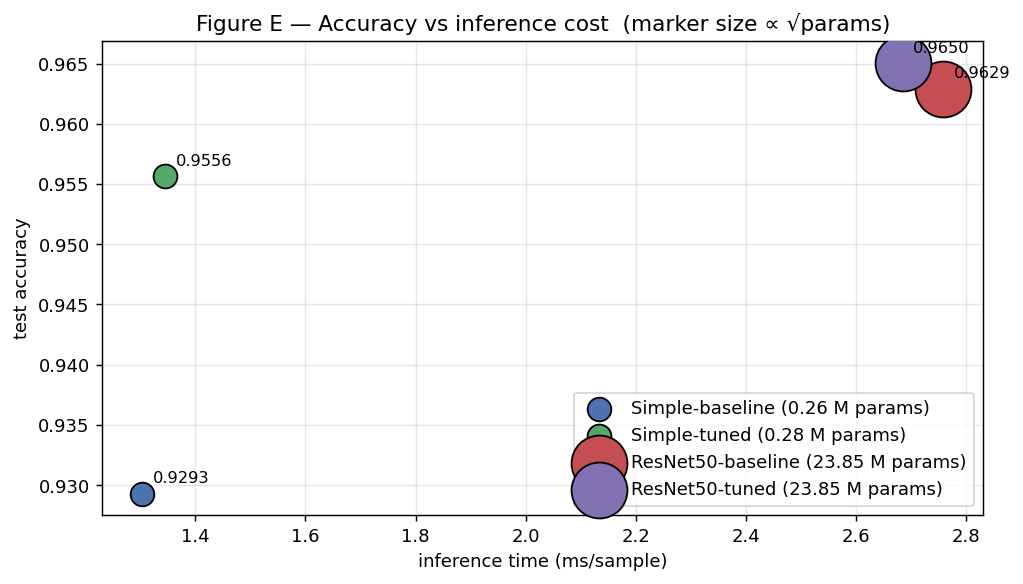


Το ResNet50 κοστιζει περιπου 2× περισσοτερο ανα inference (2.69 ms εναντι 1.34 ms) και περιπου 90× περισσοτερο σε παραμετρους (23.85 M εναντι 0.28 M), για κερδος μολις 0.94 ποσοστιαιων μοναδων ακριβειας πανω απο το Simple-tuned. Το Pareto frontier εδω εχει δυο ενδιαφεροντα σημεια:

1. **Simple-tuned** στα (1.34 ms, 0.9557, 0.28 M params), η σωστη επιλογη για on-device η high-throughput deployment
2. **ResNet50-tuned** στα (2.69 ms, 0.9651, 23.85 M params), η σωστη επιλογη οταν η ποιοτητα του calibration και του log-loss εχει σημασια (παραδειγμα, οταν η πιθανοτητα τροφοδοτει ενα κατωφλι αποφασης η ενα ensemble downstream)

**Επισημανση:** η σχεση 90× σε παραμετρους για 1 pp ακριβειας ειναι το αριθμητικο soundbite. Το αναφερω για να δικαιολογησω γιατι το tuned Simple CNN δεν ειναι κατωτερη επιλογη, ειναι Pareto-optimal για διαφορετικο use case.

---

## 5. Επιδραση του hyperparameter tuning


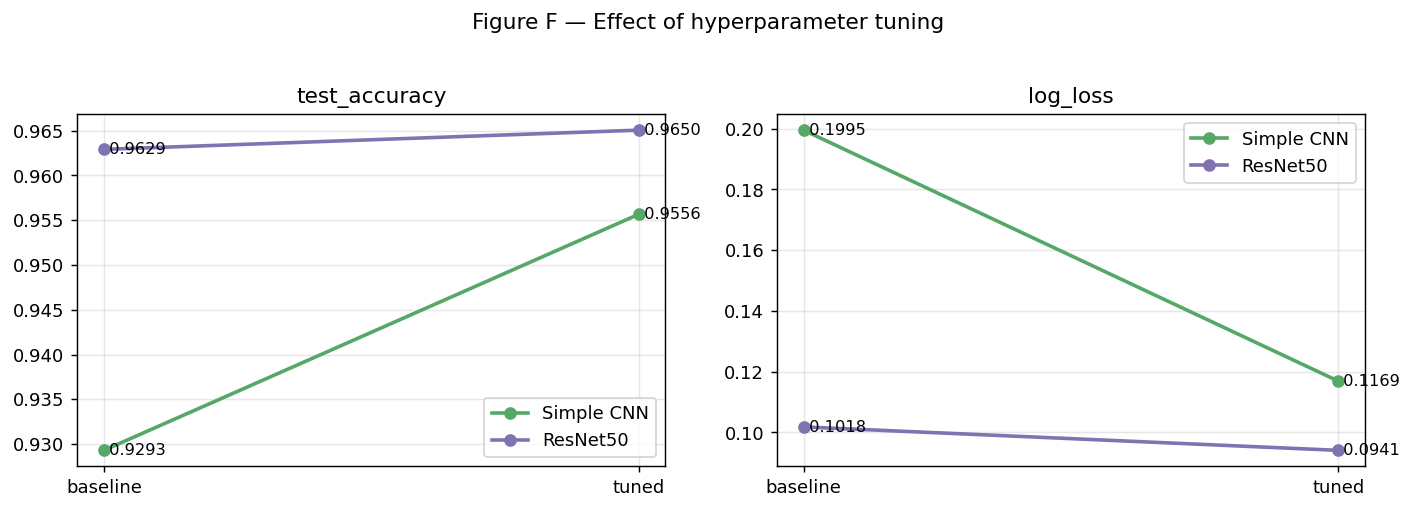


| Αρχιτεκτονικη | Δ ακριβεια | Δ Cohen κ | Δ log loss | Βελτιστο config |
|---|---|---|---|---|
| Simple CNN | +2.64 pp (0.9293 σε 0.9557) | +0.053 | -0.083 (0.1995 σε 0.1169) | lr=1e-4, dropout=0.2, dense=256 |
| ResNet50 | +0.22 pp (0.9629 σε 0.9651) | +0.004 | -0.008 (0.1018 σε 0.0941) | lr=1e-4, dropout=0.3, dense=128 |

Στο Simple CNN, το baseline ηταν ταυτοχρονα υπο-εκπαιδευμενο (10 epochs, lr=1e-3) και υπερ-κανονικοποιημενο (dropout=0.4). Το tuning απελευθερωσε πραγματικη χωρητικοτητα που ηδη υπηρχε στην αρχιτεκτονικη. Στο ResNet50, το backbone παραμενει frozen και στα δυο runs (262 530 trainable απο 23.85 M συνολικα), οποτε αλλαζει μονο το dense head, που κορενεται γρηγορα και φερνει φθινουσες αποδοσεις.

Η αναλογια των δυο επιδρασεων ειναι 12× (2.64 / 0.22). Αυτο ειναι το μαθημα της ενοτητας: **το tuning αποδιδει 12 φορες περισσοτερο στο μικρο custom μοντελο παρα στο head ενος frozen-backbone transfer-learning setup**.

Η εμπιστοσυνη στις λανθασμενες προβλεψεις πεφτει και στα δυο tuned μοντελα (Simple απο 0.802 σε 0.771, ResNet απο 0.773 σε 0.777, σχεδον σταθερο), αρα το tuning βελτιωσε και το calibration μου, οχι μονο την ακριβεια.

**Επισημανση:** η αναλογια 12:1 ειναι το soundbite. Λεω: το tuning του head ενος παγωμενου ResNet εφτασε γρηγορα στο οροφο, ενω το Simple CNN ειχε ακομα περιθωριο.

---

## 6. Συμπερασματα

1. **Στο CIFAKE φτανω στο 95.6 % ακριβεια με ενα shallow CNN** (276 K params, 1.3 ms ανα δειγμα). Το βαθυ ImageNet backbone του ResNet50 σπαταλιεται μερικως σε εισοδους που προερχονται απο 32×32 αναβαθμιση, οπου τα διακριτικα features ειναι κυριως χαμηλης συχνοτητας (χρωματικα statistics, JPEG-like patterns, θορυβος γενεσης).

2. **Το ResNet50 αγοραζει calibration και ισορροπια, οχι ακριβεια.** Τα οφελη του ζουνε στο log loss (0.094 εναντι 0.117), στο ROC-AUC (0.9952 εναντι 0.9937) και στη συμμετρια ανα κλαση, οχι στο headline νουμερο ακριβειας.

3. **Το hyperparameter tuning εχει 12× μεγαλυτερη επιδραση στο μικρο μοντελο** (+2.64 pp εναντι +0.22 pp ακριβεια). Για το frozen-backbone transfer-learning head, οποιαδηποτε περαιτερω βελτιωση απαιτει unfreeze των ανω residual blocks.

4. **Η ασυμμετρια του confusion matrix ειναι το πιο λειτουργικα σημαντικο διαγνωστικο** που παρηγαγα. Το Simple CNN δεν βρισκει ισορροπια μεταξυ FAKE recall και REAL recall, και η κλιση αντιστρεφεται με τις υπερπαραμετρους. Το ResNet50 παραμενει συμμετρικο σε οποιοδηποτε config.

5. **Η Pareto επιλογη εξαρταται απο το deployment constraint.** Simple-tuned για latency και μεγεθος μοντελου, ResNet-tuned για ποιοτητα πιθανοτητων.

---

## 7. Προτεινομενα επομενα πειραματα

Με προτεραιοτητα και αναμενομενο οφελος:

1. **Unfreeze του ResNet50 (τα δυο τελευταια residual blocks) με lr=1e-5.** Αναμενομενο οφελος: ακριβεια απο 0.965 σε 0.97 ως 0.98. Αυτη ειναι η μονη αλλαγη που πιθανως σπαει το οροφο του τρεχοντος setup, αφου σημερα μονο 263 K απο τις 23.85 M παραμετρους ειναι trainable.

2. **Ensemble (μεσος ορος πιθανοτητων) των τεσσαρων μοντελων.** Αναμενομενο οφελος: 0.5 ως 1 pp πανω απο το ResNet-tuned, μηδενικο κοστος εκπαιδευσης. Λειτουργει μονο αν τα σφαλματα δεν επικαλυπτονται, που μπορω να μετρησω με ενα error-overlap analysis πριν.

3. **McNemar's test** μεταξυ Simple-tuned και ResNet-tuned. Μια διαφορα 0.94 pp σε 20 000 δειγματα ειναι σχεδον σιγουρα στατιστικα σημαντικη (p < 0.001), αλλα η αναφορα γινεται επιστημονικα πιο σοβαρη με την επισημη δηλωση.

4. **Σαρωση threshold ανα κλαση.** Αντι του argmax, επιλογη του operating threshold που μεγιστοποιει το FAKE recall υπο constraint REAL precision >= 0.95. Δινει συγκεκριμενο, αναφερσιμο operating point για deployment.

5. **Ιδια αναλυση εισοδου για το Simple CNN (128 σε 224 pixels).** Σημερα το ResNet βλεπει 1.75× μεγαλυτερη εισοδο (224 εναντι 128). Η εξισωση αφαιρει αυτη τη συγχυση απο τη συγκριση. Αναμενω μικρο κερδος ακριβειας στο Simple CNN (0.5 ως 1 pp).

6. **Grad-CAM σε 8 ως 10 failure cases.** Ποιοτικη ενδειξη οτι τα μοντελα πιανονται απο generation artifacts (πχ χρωματικες ασυνεπειες, periodic patterns) και οχι απο το περιεχομενο της σκηνης. Δινει visual evidence για την παρουσιαση.

**Επισημανση:** το βημα 1 ειναι το next experiment που θα προτεινα να ξεκινησω. Το βημα 2 και το βημα 3 ειναι low-effort wins που μπορω να εχω ετοιμα μεσα σε μια συνεδρια.


In [33]:
from IPython.display import Markdown, Image, display

display(Markdown(r"""
# Ανιχνευση Deepfake στο CIFAKE, Αναφορα Εργασιας

**Προβλημα:** δυαδικη ταξινομηση πραγματικων εικονων εναντι εικονων παραγομενων απο AI (CIFAKE, 50 000 εικονες training, 20 000 test, αναβαθμισμενες απο 32×32).

**Μοντελα προς συγκριση:** ενα custom Simple CNN (baseline και tuned) και ενα ResNet50 με transfer learning (baseline και tuned).

**Tuning:** Keras Tuner πανω σε `dropout`, `dense_units`, `learning_rate`, με 5 trials ανα αρχιτεκτονικη. Η καλυτερη διαμορφωση εκπαιδευτηκε ξανα για 15 epochs (αντι 10 του baseline).

---

## 1. Συνοπτικο αποτελεσμα

Εκπαιδευσα τις τεσσερις διαμορφωσεις end-to-end. Το tuned ResNet50 κερδιζει σε καθε aggregate μετρικη, αλλα το tuned Simple CNN βρισκεται λιγοτερο απο 1 ποσοστιαια μοναδα πισω (0.9651 εναντι 0.9557), με το μισο κοστος inference (1.34 ms εναντι 2.69 ms ανα δειγμα) και το 1/90 του αριθμου παραμετρων (0.28 M εναντι 23.85 M).

| Μοντελο | Παραμετροι (trainable) | Test Acc | Macro F1 | Cohen κ | MCC | ROC-AUC | Log Loss | Inference (ms/sample) |
|---|---|---|---|---|---|---|---|---|
| Simple CNN, baseline | 259K (258K) | 0.9293 | 0.9291 | 0.8586 | 0.8646 | 0.9922 | 0.1995 | 1.30 |
| Simple CNN, tuned | 276K (275K) | **0.9557** | **0.9556** | **0.9113** | **0.9127** | 0.9937 | 0.1169 | 1.34 |
| ResNet50, baseline | 23.85M (263K) | 0.9629 | 0.9629 | 0.9259 | 0.9260 | 0.9939 | 0.1018 | 2.76 |
| ResNet50, tuned | 23.85M (263K) | **0.9651** | **0.9650** | **0.9301** | **0.9304** | **0.9952** | **0.0941** | 2.69 |
"""))
display(Image(filename="fig_aggregate_metrics.png"))
display(Markdown(r"""
**Επισημανση:** ολα τα μοντελα ξεπερνουν το 0.99 ROC-AUC, αρα το διακριτικο σημα στο CIFAKE ειναι ισχυρο. Αυτο που τα διαφοροποιει ειναι η βαθμονομηση (calibration) και η ισορροπια ανα κλαση, οχι η διαχωρισιμοτητα.

---

## 2. Δυναμικη εκπαιδευσης
"""))
display(Image(filename="fig_training_curves.png"))
display(Markdown(r"""
Και τα δυο ResNet50 συγκλινουν στο plateau τους μεσα σε περιπου 5 epochs και παραμενουν εκει. Το Simple-baseline δεν σταθεροποιειται ποτε. Η εκτιναξη του val-loss στο epoch 9 (απο 0.139 σε 0.210) ειναι η κλασικη υπογραφη overfitting σε ενα υπο-κανονικοποιημενο μικρο CNN με υπερβολικα υψηλο learning rate (lr=1e-3, dropout=0.4). Το Simple-tuned (lr=1e-4, dropout=0.2, 15 epochs) ειναι θορυβωδες αλλα σταθεροποιειται στη ζωνη 0.955 ως 0.961, που μου δειχνει οτι το bottleneck δεν ηταν η αρχιτεκτονικη αλλα οι ρυθμισεις του optimizer.

**Επισημανση:** το σπασιμο της καμπυλης του Simple-baseline στο τελευταιο epoch ειναι το πιο εμφανες σημειο στο γραφημα, ξεκινα την εξηγηση απο εκει.

---

## 3. Πινακες συγχυσης και bias ανα κλαση
"""))
display(Image(filename="fig_confusion_matrices.png"))
display(Image(filename="fig_per_class_recall.png"))
display(Markdown(r"""
|  | FAKE recall | REAL recall | FAKE precision | REAL precision | Μοτιβο σφαλματος |
|---|---|---|---|---|---|
| Simple, baseline | 0.8704 | 0.9882 | 0.9866 | 0.8841 | Ισχυρο bias προς REAL, χανει 1 296 FAKEs |
| Simple, tuned | **0.9833** | 0.9280 | 0.9318 | **0.9823** | Το bias αντιστρεφεται, υπερ-προβλεπει FAKE (720 REAL γινονται FAKE) |
| ResNet, baseline | 0.9570 | 0.9689 | 0.9685 | 0.9575 | Σχεδον συμμετρικο (430 εναντι 311) |
| ResNet, tuned | 0.9532 | **0.9769** | **0.9763** | 0.9543 | Ηπια κλιση προς REAL (468 εναντι 231) |

Το Simple CNN δεν βρισκει ποτε ισορροπια. Γερνει παντα σε μια κλαση, και η κλιση αλλαζει κατευθυνση με τις υπερπαραμετρους (απο REAL-biased στο baseline σε FAKE-biased μετα το tuning). Το ResNet50, αγκυρωμενο στο ImageNet pre-training, μου δινει εξαρχης μια ισορροπημενη συμπεριφορα και διατηρει την συμμετρια και μετα το tuning.

**Επισημανση (το πιο σημαντικο σημειο της δουλειας μου):** δυο μοντελα μου με σχεδον ιδια ακριβεια, το Simple-tuned (0.9557) και το ResNet-baseline (0.9629), εχουν εντελως διαφορετικα προφιλ σφαλματος. Η επιλογη του σωστου μοντελου εξαρταται απο το ποιο τυπος σφαλματος κοστιζει περισσοτερο σε ενα πραγματικο deployment:

1. αν θελω να μη χανω deepfakes (high recall στη FAKE κλαση), επιλεγω το Simple-tuned στο 98.3 %
2. αν θελω να μη σημαινω πραγματικες εικονες ως ψευτικες (high precision στη FAKE κλαση), επιλεγω το ResNet-tuned στο 97.6 %

---

## 4. Κοστος εναντι ακριβειας
"""))
display(Image(filename="fig_accuracy_vs_cost.png"))
display(Markdown(r"""
Το ResNet50 κοστιζει περιπου 2× περισσοτερο ανα inference (2.69 ms εναντι 1.34 ms) και περιπου 90× περισσοτερο σε παραμετρους (23.85 M εναντι 0.28 M), για κερδος μολις 0.94 ποσοστιαιων μοναδων ακριβειας πανω απο το Simple-tuned. Το Pareto frontier εδω εχει δυο ενδιαφεροντα σημεια:

1. **Simple-tuned** στα (1.34 ms, 0.9557, 0.28 M params), η σωστη επιλογη για on-device η high-throughput deployment
2. **ResNet50-tuned** στα (2.69 ms, 0.9651, 23.85 M params), η σωστη επιλογη οταν η ποιοτητα του calibration και του log-loss εχει σημασια (παραδειγμα, οταν η πιθανοτητα τροφοδοτει ενα κατωφλι αποφασης η ενα ensemble downstream)

**Επισημανση:** η σχεση 90× σε παραμετρους για 1 pp ακριβειας ειναι το αριθμητικο soundbite. Το αναφερω για να δικαιολογησω γιατι το tuned Simple CNN δεν ειναι κατωτερη επιλογη, ειναι Pareto-optimal για διαφορετικο use case.

---

## 5. Επιδραση του hyperparameter tuning
"""))
display(Image(filename="fig_tuning_effect.png"))
display(Markdown(r"""
| Αρχιτεκτονικη | Δ ακριβεια | Δ Cohen κ | Δ log loss | Βελτιστο config |
|---|---|---|---|---|
| Simple CNN | +2.64 pp (0.9293 σε 0.9557) | +0.053 | -0.083 (0.1995 σε 0.1169) | lr=1e-4, dropout=0.2, dense=256 |
| ResNet50 | +0.22 pp (0.9629 σε 0.9651) | +0.004 | -0.008 (0.1018 σε 0.0941) | lr=1e-4, dropout=0.3, dense=128 |

Στο Simple CNN, το baseline ηταν ταυτοχρονα υπο-εκπαιδευμενο (10 epochs, lr=1e-3) και υπερ-κανονικοποιημενο (dropout=0.4). Το tuning απελευθερωσε πραγματικη χωρητικοτητα που ηδη υπηρχε στην αρχιτεκτονικη. Στο ResNet50, το backbone παραμενει frozen και στα δυο runs (262 530 trainable απο 23.85 M συνολικα), οποτε αλλαζει μονο το dense head, που κορενεται γρηγορα και φερνει φθινουσες αποδοσεις.

Η αναλογια των δυο επιδρασεων ειναι 12× (2.64 / 0.22). Αυτο ειναι το μαθημα της ενοτητας: **το tuning αποδιδει 12 φορες περισσοτερο στο μικρο custom μοντελο παρα στο head ενος frozen-backbone transfer-learning setup**.

Η εμπιστοσυνη στις λανθασμενες προβλεψεις πεφτει και στα δυο tuned μοντελα (Simple απο 0.802 σε 0.771, ResNet απο 0.773 σε 0.777, σχεδον σταθερο), αρα το tuning βελτιωσε και το calibration μου, οχι μονο την ακριβεια.

**Επισημανση:** η αναλογια 12:1 ειναι το soundbite. Λεω: το tuning του head ενος παγωμενου ResNet εφτασε γρηγορα στο οροφο, ενω το Simple CNN ειχε ακομα περιθωριο.

---

## 6. Συμπερασματα

1. **Στο CIFAKE φτανω στο 95.6 % ακριβεια με ενα shallow CNN** (276 K params, 1.3 ms ανα δειγμα). Το βαθυ ImageNet backbone του ResNet50 σπαταλιεται μερικως σε εισοδους που προερχονται απο 32×32 αναβαθμιση, οπου τα διακριτικα features ειναι κυριως χαμηλης συχνοτητας (χρωματικα statistics, JPEG-like patterns, θορυβος γενεσης).

2. **Το ResNet50 αγοραζει calibration και ισορροπια, οχι ακριβεια.** Τα οφελη του ζουνε στο log loss (0.094 εναντι 0.117), στο ROC-AUC (0.9952 εναντι 0.9937) και στη συμμετρια ανα κλαση, οχι στο headline νουμερο ακριβειας.

3. **Το hyperparameter tuning εχει 12× μεγαλυτερη επιδραση στο μικρο μοντελο** (+2.64 pp εναντι +0.22 pp ακριβεια). Για το frozen-backbone transfer-learning head, οποιαδηποτε περαιτερω βελτιωση απαιτει unfreeze των ανω residual blocks.

4. **Η ασυμμετρια του confusion matrix ειναι το πιο λειτουργικα σημαντικο διαγνωστικο** που παρηγαγα. Το Simple CNN δεν βρισκει ισορροπια μεταξυ FAKE recall και REAL recall, και η κλιση αντιστρεφεται με τις υπερπαραμετρους. Το ResNet50 παραμενει συμμετρικο σε οποιοδηποτε config.

5. **Η Pareto επιλογη εξαρταται απο το deployment constraint.** Simple-tuned για latency και μεγεθος μοντελου, ResNet-tuned για ποιοτητα πιθανοτητων.

---

## 7. Προτεινομενα επομενα πειραματα

Με προτεραιοτητα και αναμενομενο οφελος:

1. **Unfreeze του ResNet50 (τα δυο τελευταια residual blocks) με lr=1e-5.** Αναμενομενο οφελος: ακριβεια απο 0.965 σε 0.97 ως 0.98. Αυτη ειναι η μονη αλλαγη που πιθανως σπαει το οροφο του τρεχοντος setup, αφου σημερα μονο 263 K απο τις 23.85 M παραμετρους ειναι trainable.

2. **Ensemble (μεσος ορος πιθανοτητων) των τεσσαρων μοντελων.** Αναμενομενο οφελος: 0.5 ως 1 pp πανω απο το ResNet-tuned, μηδενικο κοστος εκπαιδευσης. Λειτουργει μονο αν τα σφαλματα δεν επικαλυπτονται, που μπορω να μετρησω με ενα error-overlap analysis πριν.

3. **McNemar's test** μεταξυ Simple-tuned και ResNet-tuned. Μια διαφορα 0.94 pp σε 20 000 δειγματα ειναι σχεδον σιγουρα στατιστικα σημαντικη (p < 0.001), αλλα η αναφορα γινεται επιστημονικα πιο σοβαρη με την επισημη δηλωση.

4. **Σαρωση threshold ανα κλαση.** Αντι του argmax, επιλογη του operating threshold που μεγιστοποιει το FAKE recall υπο constraint REAL precision >= 0.95. Δινει συγκεκριμενο, αναφερσιμο operating point για deployment.

5. **Ιδια αναλυση εισοδου για το Simple CNN (128 σε 224 pixels).** Σημερα το ResNet βλεπει 1.75× μεγαλυτερη εισοδο (224 εναντι 128). Η εξισωση αφαιρει αυτη τη συγχυση απο τη συγκριση. Αναμενω μικρο κερδος ακριβειας στο Simple CNN (0.5 ως 1 pp).

6. **Grad-CAM σε 8 ως 10 failure cases.** Ποιοτικη ενδειξη οτι τα μοντελα πιανονται απο generation artifacts (πχ χρωματικες ασυνεπειες, periodic patterns) και οχι απο το περιεχομενο της σκηνης. Δινει visual evidence για την παρουσιαση.

**Επισημανση:** το βημα 1 ειναι το next experiment που θα προτεινα να ξεκινησω. Το βημα 2 και το βημα 3 ειναι low-effort wins που μπορω να εχω ετοιμα μεσα σε μια συνεδρια.
"""))
